In [2]:
import os
from dotenv import load_dotenv

In [3]:
# Load variables from .env into the shell environment
load_dotenv()


True

In [6]:
from IPython.display import Image, display
from typing import Literal

from langchain_openai import ChatOpenAI
from langchain_core.messages import (SystemMessage,
                                     HumanMessage,
                                     ToolMessage,
                                     RemoveMessage)
from langchain_core.runnables import RunnableConfig

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState

model = ChatOpenAI(model="gpt-4o", temperature=0)

In [15]:
class ChatState(MessagesState):
    summary: str


# Define the nodes
def converstaion(state: ChatState, config: RunnableConfig):

    # Get the summary if it exists
    summary = state.get("summary", "")

    if summary:
        system_message = f"Summary of converstaion so far: {summary}"

        messages = [SystemMessage(content=system_message)] + state["messages"]
    else:
        messages = state["messages"]
    
    response = model.invoke(messages, config)
    return {"messages": response}


def summarize_converstaion(state: ChatState):
    
    summary = state.get("summary", "")

    if summary:
        summary_message = (
            f"This is the summary of converstion so far: {summary}"
            "Extend it by taking into command the new messages above"
        )
    else:
        summary_message = (
            f"Create a summary of the conversation messages"
            "above"
        )
        
    response = model.invoke(state["messages"] + [HumanMessage(content=summary_message)])

    # Delete all the messages except the last two
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"summary": response.content, "messages": delete_messages}


def summary_required(state: ChatState) -> Literal["summarize_converstaion", END]:
    
    messages = state["messages"]

    return "summarize_converstaion" if len(messages) > 6 else END
        

        

In [16]:
workflow = StateGraph(ChatState)

workflow.add_node("converstaion", converstaion)
workflow.add_node("summarize_converstaion", summarize_converstaion)

workflow.add_edge(START, "converstaion")
workflow.add_conditional_edges(
    "converstaion",
    summary_required
)
workflow.add_edge("summarize_converstaion", END)

memory = MemorySaver()
graph = workflow.compile(checkpointer=memory)


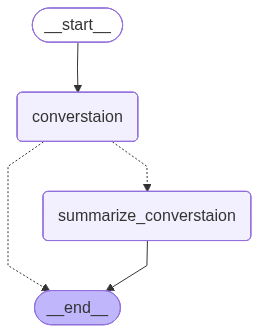

In [17]:
display(Image(graph.get_graph().draw_mermaid_png()))

## Streaming

In [29]:
# Create a thread
config = {"configurable": {"thread_id": "1"}}

# Start conversation
for event in graph.stream({"messages": [HumanMessage(content="hi! I am interested in knowing about Narendra Modi and Mansi Soni")]}, 
                          config=config, stream_mode="values"):
    for m in event['messages']:
        print(m.pretty_print())

================================ Human Message =================================

hi! I am interested in knowing about Taj Mahal
None
================================== Ai Message ==================================

The Taj Mahal is one of the most iconic and beautiful monuments in the world, renowned for its stunning architecture and historical significance. Here are some key points about the Taj Mahal:

1. **Location**: The Taj Mahal is located in Agra, a city in the northern Indian state of Uttar Pradesh, on the banks of the Yamuna River.

2. **Historical Background**: The Taj Mahal was commissioned by the Mughal Emperor Shah Jahan in 1632 in memory of his beloved wife Mumtaz Mahal, who died during childbirth. It serves as her mausoleum.

3. **Architecture**: The Taj Mahal is an exquisite example of Mughal architecture, which combines elements from Islamic, Persian, Ottoman Turkish, and Indian architectural styles. It is primarily made of white marble and is adorned with intricate c

## Human Feedback

In [31]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b

    Args:
        a: first integer
        b: second integer
    """

def add(a: int, b: int) -> int:
    """Add two integers a and b
    
    Args:
        a: an integer
        b: an integer
    """
    return a + b


def divide(a: int, b: int) -> float:
    """Divide two integers a and b
    
    Args:
        a: an integer
        b: an integer
    """
    return a / b

tools = [multiply, add, divide]

In [32]:
llm_with_tools = model.bind_tools(tools)

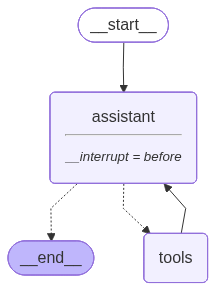

In [33]:
from langgraph.prebuilt import tools_condition, ToolNode

system_message = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic set of operations on inputs.")

# Node
def assistant(state: MessagesState):
    result = llm_with_tools.invoke([system_message] + state["messages"])
    return {"messages": [result]}

# Graph
builder = StateGraph(MessagesState)

# Nodes
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    tools_condition
)
builder.add_edge("tools", "assistant")

memory = MemorySaver()
graph = builder.compile(interrupt_before=["assistant"], checkpointer=memory)

# Display graph

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))


In [34]:
initial_input = {"messages": "Multiply 2 and 3"}

thread = {"configurable": {"thread_id": "1"}}

for event in graph.stream(initial_input, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3


In [35]:
state = graph.get_state(thread)
state

StateSnapshot(values={'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='6fcf8dd1-b59f-47e6-a3c3-0ed726208631')]}, next=('assistant',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f144af3-5fca-6da3-8000-98184f73e8b8'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-04-30T16:11:14.091345+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f144af3-5fc8-65ae-bfff-bcb156cd7f8a'}}, tasks=(PregelTask(id='62ee8d03-7fc1-4012-4bd0-4a7d903bd1ea', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [36]:
graph.update_state(
    thread,
    {"messages": [HumanMessage(content="No actually divide 10 by 2")]}
)


{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f144af8-0192-6eb4-8001-0e5ccb739eb3'}}

In [37]:
new_state = graph.get_state(thread).values
for m in new_state["messages"]:
    m.pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================ Human Message =================================

No actually divide 10 by 2


In [38]:
for event in graph.stream(None, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

No actually divide 10 by 2
================================== Ai Message ==================================
Tool Calls:
  divide (call_HEzVoTriHhxGTcFG9T5IH6Vb)
 Call ID: call_HEzVoTriHhxGTcFG9T5IH6Vb
  Args:
    a: 10
    b: 2
================================= Tool Message =================================
Name: divide

5.0


In [39]:
for event in graph.stream(None, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================= Tool Message =================================
Name: divide

5.0
================================== Ai Message ==================================

The result of dividing 10 by 2 is 5.0.
